In [23]:
import cv2
import numpy as np
import sys
import os

In [24]:
def load_image(path):
    image = cv2.imread(path)
    if image is None:
        raise FileNotFoundError(f"Could not load image: {path}")
    print(f"[1] Loaded image  →  {image.shape[1]}×{image.shape[0]} px")
    return image

def resize_image(image, max_side=1024):
    h, w = image.shape[:2]
    scale = min(max_side / max(h, w), 1.0)
    resized = cv2.resize(image, (int(w*scale), int(h*scale)), interpolation=cv2.INTER_AREA)
    print(f"[2] Resized  →  {int(w*scale)}×{int(h*scale)} px")
    return resized, scale

def apply_blur(image, kernel=5):
    print(f"[3] Gaussian blur applied")
    return cv2.GaussianBlur(image, (kernel, kernel), 0)

def to_grayscale(image):
    print(f"[4] Converted to grayscale")
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

def detect_edges(gray, low=75, high=200):
    edges = cv2.Canny(gray, low, high)
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3,3))
    edges = cv2.dilate(edges, kernel, iterations=1)
    print(f"[5] Edges detected")
    return edges

def find_document_contour(edges):
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    for cnt in contours[:5]:
        peri = cv2.arcLength(cnt, True)
        approx = cv2.approxPolyDP(cnt, 0.02 * peri, True)
        if len(approx) == 4:
            print(f"[6] Document contour found")
            return approx
    return None

def order_points(pts):
    pts = pts.reshape(4, 2).astype("float32")
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]
    rect[2] = pts[np.argmax(s)]
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)]
    rect[3] = pts[np.argmax(diff)]
    return rect

def crop_document(image, contour):
    if contour is None:
        return image
    rect = order_points(contour)
    tl, tr, br, bl = rect
    width  = int(max(np.linalg.norm(br-bl), np.linalg.norm(tr-tl)))
    height = int(max(np.linalg.norm(tr-br), np.linalg.norm(tl-bl)))
    dst = np.array([[0,0],[width-1,0],[width-1,height-1],[0,height-1]], dtype="float32")
    M = cv2.getPerspectiveTransform(rect, dst)
    print(f"[6] Document cropped  →  {width}×{height} px")
    return cv2.warpPerspective(image, M, (width, height))

def apply_threshold(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY) if len(image.shape)==3 else image
    scanned = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                    cv2.THRESH_BINARY, 21, 10)
    print(f"[7] Threshold applied")
    return scanned

def draw_boundaries(image, contour):
    preview = image.copy()
    if contour is not None:
        cv2.drawContours(preview, [contour], -1, (0,255,80), 3)
        for pt in contour.reshape(-1, 2):
            cv2.circle(preview, tuple(pt), 8, (0,200,255), -1)
    print(f"[8] Boundaries drawn")
    return preview

def save_output(scanned, preview, out_dir="output"):
    os.makedirs(out_dir, exist_ok=True)
    cv2.imwrite(os.path.join(out_dir, "scanned_document.png"), scanned)
    cv2.imwrite(os.path.join(out_dir, "detected_boundary.png"), preview)
    print(f"[9] Saved to '{out_dir}' folder")

In [25]:

IMAGE_PATH = "Introduction.jpg"

original          = load_image(IMAGE_PATH)
resized, scale    = resize_image(original)
blurred           = apply_blur(resized)
gray              = to_grayscale(blurred)
edges             = detect_edges(gray)
contour           = find_document_contour(edges)
cropped           = crop_document(resized, contour)
scanned           = apply_threshold(cropped)
preview           = draw_boundaries(resized, contour)
save_output(scanned, preview)

[1] Loaded image  →  768×1024 px
[2] Resized  →  768×1024 px
[3] Gaussian blur applied
[4] Converted to grayscale
[5] Edges detected
[7] Threshold applied
[8] Boundaries drawn
[9] Saved to 'output' folder


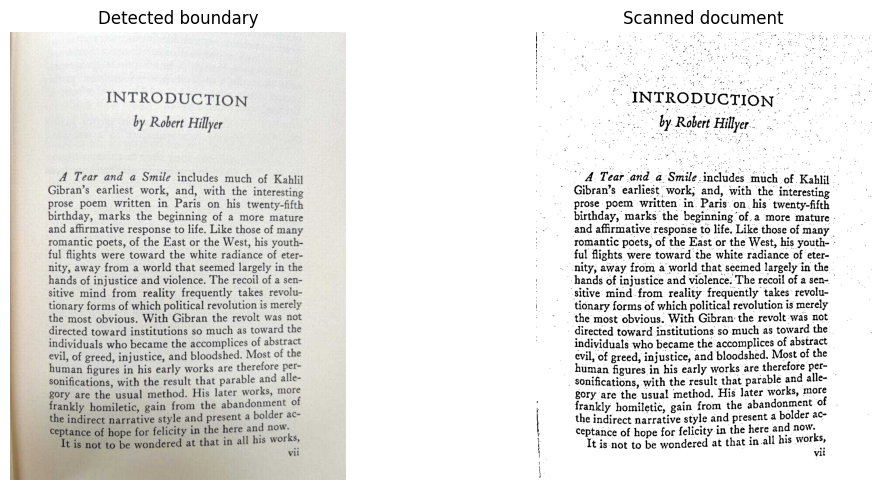

In [26]:
from matplotlib import pyplot as plt

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
plt.title("Detected boundary")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(scanned, cmap="gray")
plt.title("Scanned document")
plt.axis("off")

plt.tight_layout()
plt.show()

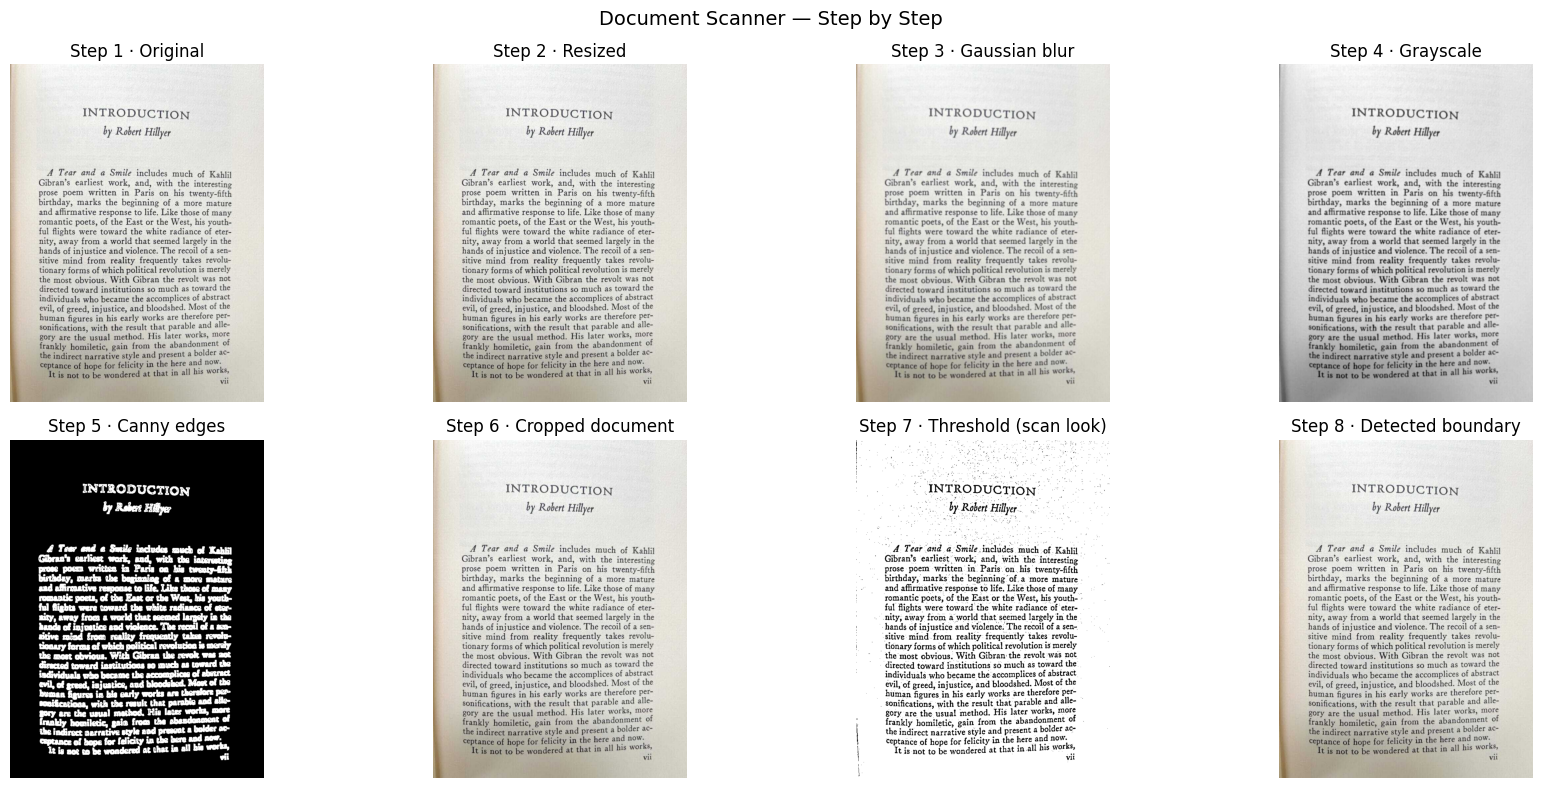

In [27]:
from matplotlib import pyplot as plt
import cv2

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle("Document Scanner — Step by Step", fontsize=14)

# Step 1 - Original
axes[0,0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0,0].set_title("Step 1 · Original")
axes[0,0].axis("off")

# Step 2 - Resized
axes[0,1].imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2RGB))
axes[0,1].set_title("Step 2 · Resized")
axes[0,1].axis("off")

# Step 3 - Blurred
axes[0,2].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axes[0,2].set_title("Step 3 · Gaussian blur")
axes[0,2].axis("off")

# Step 4 - Grayscale
axes[0,3].imshow(gray, cmap="gray")
axes[0,3].set_title("Step 4 · Grayscale")
axes[0,3].axis("off")

# Step 5 - Edges
axes[1,0].imshow(edges, cmap="gray")
axes[1,0].set_title("Step 5 · Canny edges")
axes[1,0].axis("off")

# Step 6 - Cropped
axes[1,1].imshow(cv2.cvtColor(cropped, cv2.COLOR_BGR2RGB))
axes[1,1].set_title("Step 6 · Cropped document")
axes[1,1].axis("off")

# Step 7 - Threshold
axes[1,2].imshow(scanned, cmap="gray")
axes[1,2].set_title("Step 7 · Threshold (scan look)")
axes[1,2].axis("off")

# Step 8 - Boundaries drawn
axes[1,3].imshow(cv2.cvtColor(preview, cv2.COLOR_BGR2RGB))
axes[1,3].set_title("Step 8 · Detected boundary")
axes[1,3].axis("off")

plt.tight_layout()
plt.show()